# Bài tập lập trình — Môn 121036
## Bài 1: Lọc tần số | Bài 2: Phát hiện đặc trưng

**Hướng dẫn:**
- Cài đặt **từ đầu (from scratch)** — không dùng hàm sẵn thực hiện chức năng chính
- Được dùng: `numpy`, `matplotlib`, `scipy.ndimage` (chỉ cho convolution phụ trợ)
- Chạy toàn bộ notebook từ đầu đến cuối không có lỗi trước khi nộp
- Phải có kết quả ảnh được xử lý và nêu được sự khác biệt với một vài tham số liên quan


## Import

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Chỉ dùng cho convolution phụ trợ (kiểm chứng) và NMS
from scipy.ndimage import maximum_filter
from scipy.ndimage import gaussian_filter

%matplotlib inline
plt.rcParams['figure.dpi'] = 120


## Ảnh thử nghiệm

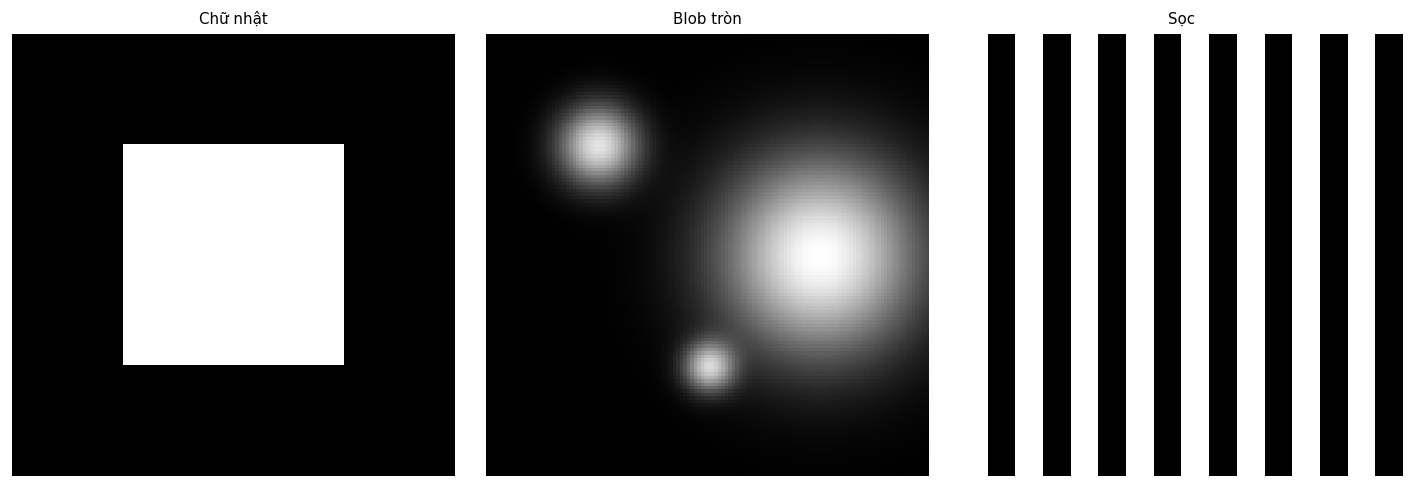

In [2]:
def make_test_image(kind='rect', N=128):
    """Tạo ảnh tổng hợp để thử nghiệm."""
    img = np.zeros((N, N), dtype=np.float64)
    if kind == 'rect':
        img[N//4:3*N//4, N//4:3*N//4] = 1.0
    elif kind == 'circles':
        yy, xx = np.ogrid[:N, :N]
        img += 0.8 * np.exp(-((xx-N//4)**2 + (yy-N//4)**2) / (2*8**2))
        img += 0.9 * np.exp(-((xx-3*N//4)**2 + (yy-N//2)**2) / (2*20**2))
        img += 0.7 * np.exp(-((xx-N//2)**2 + (yy-3*N//4)**2) / (2*5**2))
        img = np.clip(img, 0, 1)
    elif kind == 'stripe':
        for i in range(0, N, 16):
            img[:, i:i+8] = 1.0
    elif kind == 'noise':
        rng = np.random.default_rng(42)
        img = rng.random((N, N))
    return img

def show_images(imgs, titles, cmap='gray', figsize=None):
    n = len(imgs)
    figsize = figsize or (4*n, 4)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1: axes = [axes]
    for ax, img, title in zip(axes, imgs, titles):
        ax.imshow(img, cmap=cmap, vmin=img.min(), vmax=img.max())
        ax.set_title(title, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Kiểm tra
img_rect    = make_test_image('rect', 128)
img_circles = make_test_image('circles', 128)
img_stripe  = make_test_image('stripe', 128)
show_images([img_rect, img_circles, img_stripe],
            ['Chữ nhật', 'Blob tròn', 'Sọc'])


---
# Bài 1 — Lọc trong miền tần số


## 1.1 Biến đổi Fourier rời rạc 2D (từ đầu)

**Công thức:**
$$F(u,v) = \sum_{x=0}^{M-1}\sum_{y=0}^{N-1} f(x,y)\,e^{-j2\pi\left(\frac{ux}{M}+\frac{vy}{N}\right)}$$

**Yêu cầu:** Cài đặt hàm `my_dft2` và `my_idft2`. Kiểm chứng bằng `np.allclose`.

> **Gợi ý:** DFT 2D = DFT 1D theo từng hàng, rồi DFT 1D theo từng cột kết quả.
> Vectorise bằng broadcasting để tránh 4 vòng lặp lồng nhau.


In [3]:
# Biến đổi tín hiệu 1 chiều: [1,2,3,4]->[X0,X1,X2,X3]
def my_dft1(x):
    """DFT 1D từ đầu.
    
    Args:
        x: array 1D, độ dài N
    Returns:
        X: array 1D phức, độ dài N
    """
    # TODO: cài đặt DFT 1D
    # Gợi ý: tạo ma trận twiddle W[n,k] = exp(-j2pi*n*k/N)
    # rồi X = W @ x

    # Ép dữ liệu thành số phức
    # vd:[1,2,3] ->[1.+0.j, 2.+0.j, 3.+0.j]
    x = np.asarray(x, dtype=np.complex128) 

    # Lấy số mẫu: DFT cần biết chiều dài tín hiệu
    N = len(x) 

    # n là chỉ số vị trí trong tín hiệu.
    n = np.arange(N)

    # reshape để broadcasting tạo ma trận Fourier.
    k = n.reshape((N, 1))

    # Ma trận Fourier: Biểu diễn CT DFT bằng ma trận không dùng vòng lặp
    W = np.exp(-2j * np.pi * k * n / N)

    # Nhân ma trận 
    X = W @ x

    return X

def my_dft2(f):
    """DFT 2D từ đầu bằng cách áp DFT 1D theo hàng rồi cột.
    
    Args:
        f: array 2D thực, kích thước M×N
    Returns:
        F: array 2D phức, kích thước M×N
    """
    # TODO: áp my_dft1 theo từng hàng, sau đó theo từng cột

    #DFT theo trận, temp chứa ảnh sau khi DFT chiều ngang
    temp = np.array(
        [my_dft1(row) for row in f]
    )
    #DFT theo cột, biến cột thành hàng
    F = np.array(
        [my_dft1(col) for col in temp.T]
    ).T

    return F


def my_idft2(F):
    """IDFT 2D từ đầu.
    
    Args:
        F: array 2D phức
    Returns:
        f: array 2D thực (lấy phần thực)
    """
    # Gợi ý: IDFT = conjugate(DFT(conjugate(F))) / MN
    # hoặc đổi dấu số mũ trong công thức DFT

    #Lấy kích thước
    M, N = F.shape #vd: 16x16

    #Lấy liên hợp phức 
    F_conj = np.conjugate(F) #vd: 3 + 2j -> 3 - 2j

    #DFT lại
    temp = my_dft2(F_conj)

    #lấy liên hợp lần nữa
    f = np.conjugate(temp)
     
    f = f / (M * N)

    #Chia lấy phần thực
    return np.real(f)


In [4]:
# Kiểm chứng
f_small = make_test_image('rect', N=16)  # dùng ảnh nhỏ vì DFT naive chậm

F_mine = my_dft2(f_small)
F_numpy = np.fft.fft2(f_small)

print('DFT 2D - allclose:', np.allclose(F_mine, F_numpy, atol=1e-6))

f_recovered = my_idft2(F_mine)
print('IDFT 2D - allclose:', np.allclose(f_small, f_recovered, atol=1e-6))


DFT 2D - allclose: True
IDFT 2D - allclose: True


## 1.2 Hiển thị phổ biên độ và pha

Sau `fftshift`, tần số DC nằm ở trung tâm. Phổ biên độ thường hiển thị dưới dạng log.


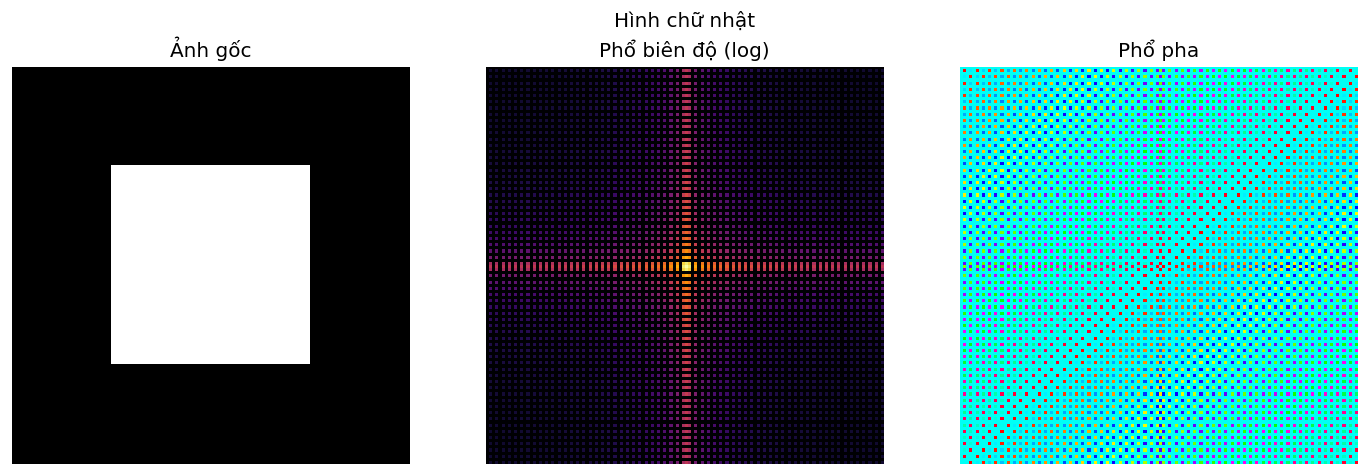

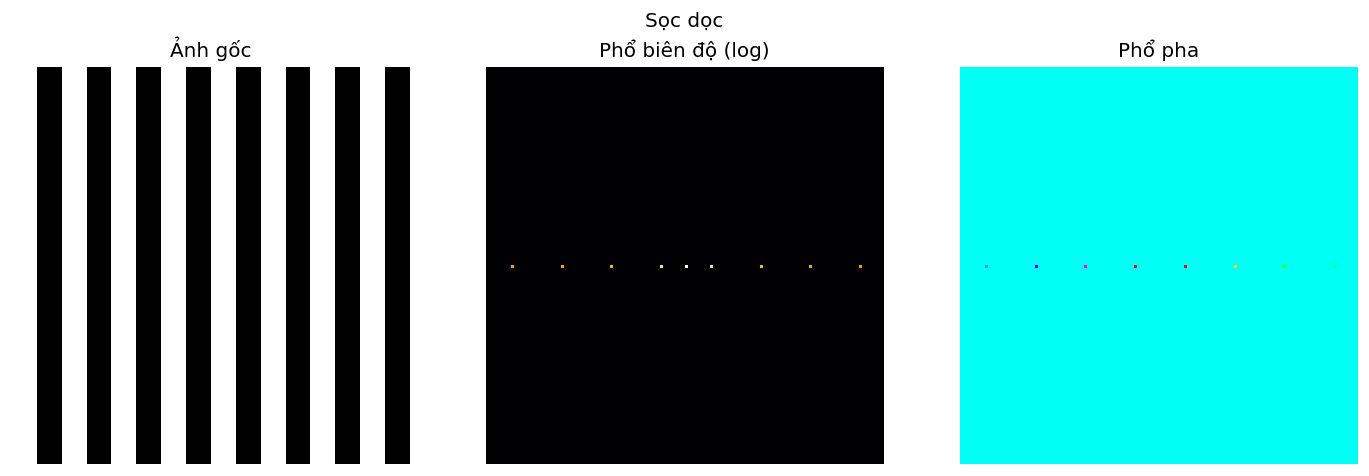

In [5]:
def show_spectrum(f, title=''):
    """Hiển thị ảnh gốc, phổ biên độ (log), và phổ pha."""
    F = np.fft.fftshift(np.fft.fft2(f))
    mag   = np.abs(F)
    phase = np.angle(F)
    log_mag = np.log1p(mag)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(f, cmap='gray'); axes[0].set_title('Ảnh gốc')
    axes[1].imshow(log_mag, cmap='inferno'); axes[1].set_title('Phổ biên độ (log)')
    axes[2].imshow(phase, cmap='hsv'); axes[2].set_title('Phổ pha')
    for ax in axes: ax.axis('off')
    if title: fig.suptitle(title)
    plt.tight_layout(); plt.show()

show_spectrum(img_rect, 'Hình chữ nhật')
show_spectrum(img_stripe, 'Sọc dọc')


## 1.3 Quy trình lọc tổng quát

Mọi bộ lọc đều dùng quy trình: `fft2` → `fftshift` → nhân $H$ → `ifftshift` → `ifft2` → lấy phần thực.


In [6]:
def apply_filter(f, H):
    F  = np.fft.fft2(f)
    Fs = np.fft.fftshift(F)
    Gs = Fs * H
    g  = np.real(np.fft.ifft2(np.fft.ifftshift(Gs)))
    return g

def freq_coords(M, N):
    u  = np.arange(M) - M // 2
    v  = np.arange(N) - N // 2
    UU, VV = np.meshgrid(u, v, indexing='ij')
    return np.sqrt(UU**2 + VV**2)

## 1.4 Lọc lý tưởng (Ideal LP/HP)

$$H_{LP}^{ideal}(u,v) = \begin{cases}1 & D(u,v)\le D_0\\0 & D(u,v)>D_0\end{cases}$$

Quan sát hiện tượng Gibbs (ringing) xung quanh biên sau khi lọc.


In [7]:
def ideal_lp(shape, D0):
    """Bộ lọc thông thấp lý tưởng. shape=(M,N), D0: tần số cắt."""
    M, N = shape
    u = np.arange(M)
    v = np.arange(N)
    # dịch gốc tọa độ về tâm
    u = np.where(u > M // 2, u - M, u)
    v = np.where(v > N // 2, v - N, v)
    V, U = np.meshgrid(v, u)
    D = np.sqrt(U**2 + V**2)
    H = (D <= D0).astype(np.float64)
    return H

def ideal_hp(shape, D0):
    """Bộ lọc thông cao lý tưởng = 1 - thông thấp."""
    return 1.0 - ideal_lp(shape, D0)

In [8]:
# Thử nghiệm với các D0 khác nhau
M, N = img_rect.shape
for D0 in [10, 20, 40]:
    H_lp = ideal_lp(M, N, D0)
    H_hp = ideal_hp(M, N, D0)
    g_lp = apply_filter(img_rect, H_lp)
    g_hp = apply_filter(img_rect, H_hp)
    show_images(
        [H_lp, g_lp, H_hp, g_hp],
        [f'H_LP (D0={D0})', f'Sau LP (D0={D0})',
         f'H_HP (D0={D0})', f'Sau HP (D0={D0})'],
        figsize=(14, 3.5)
    )


TypeError: ideal_lp() takes 2 positional arguments but 3 were given

**Giải thích:** (điền vào đây)
- Hiện tượng Gibbs xảy ra khi nào?
- D0 ảnh hưởng đến kết quả thế nào?


## 1.5 Lọc Butterworth

$$H_{LP}^{BW}(u,v) = \frac{1}{1+\left[D(u,v)/D_0\right]^{2n}}$$

Tại $D=D_0$: $H=0.5$ với mọi $n$. Khi $n\to\infty$ tiệm cận lọc lý tưởng.


In [ ]:
def butterworth_lp(M, N, D0, n):
    """Mask lọc thấp Butterworth bậc n."""
    D = freq_coords(M, N)

    H = 1 / (1 + (D / D0) ** (2 * n))

    return H

def butterworth_hp(M, N, D0, n):
    """Mask lọc cao Butterworth bậc n."""
    
    H_lp = butterworth_lp(M, N, D0, n)

    return 1 - H_lp


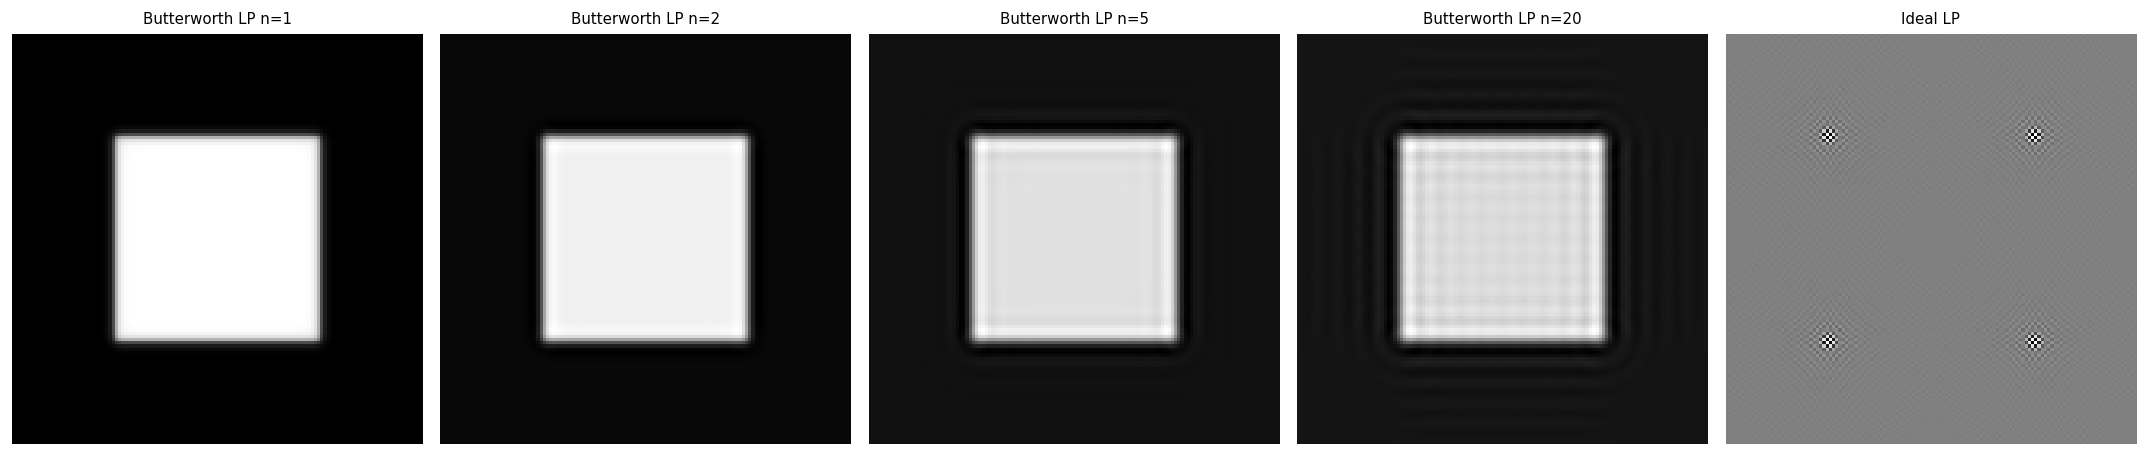

In [ ]:
# So sánh Butterworth bậc khác nhau với Ideal
D0, M, N = 20, *img_rect.shape
results = []
titles  = []
for order in [1, 2, 5, 20]:
    H = butterworth_lp(M, N, D0, order)
    results.append(apply_filter(img_rect, H))
    titles.append(f'Butterworth LP n={order}')
results.append(apply_filter(img_rect, ideal_lp((M, N), D0)))
titles.append('Ideal LP')
show_images(results, titles, figsize=(18, 4))


## 1.6 Lọc băng thông (Band-pass)

$$H_{BP}(u,v) = H_{LP}(u,v;\,D_{high}) - H_{LP}(u,v;\,D_{low})$$

Chỉ cho qua tần số trong dải $[D_{low}, D_{high}]$.


In [ ]:
def butterworth_lp(M, N, D0, n):
    """Mặt nạ lọc thấp (Low-pass) Butterworth bậc n."""
    # Tái sử dụng hàm freq_coords đã cho sẵn trong bài
    D = freq_coords(M, N)
    
    # Tránh chia cho 0 nếu D0 = 0
    eps = 1e-8
    
    H = 1.0 / (1.0 + (D / (D0 + eps))**(2 * n))
    return H

def butterworth_bp(M, N, D_low, D_high, n):
    """Mạc nạ lọc băng thông (Band-pass) Butterworth."""
    # Định công thức theo đúng yêu cầu đề bài: H_BP = H_LP(D_high) - H_LP(D_low)
    H_high = butterworth_lp(M, N, D_high, n)
    H_low  = butterworth_lp(M, N, D_low, n)
    
    H_bp = H_high - H_low
    return H_bp

In [ ]:
M, N = img_circles.shape
for D_lo, D_hi in [(5, 15), (15, 30), (30, 55)]:
    H = butterworth_bp(M, N, D_lo, D_hi, n=2)
    g = apply_filter(img_circles, H)
    show_images([H, g],
                [f'H_BP [{D_lo},{D_hi}]', f'Sau BP [{D_lo},{D_hi}]'],
                figsize=(8, 4))


## 1.7 Lọc Notch

Chặn một tần số cụ thể $(u_0, v_0)$ và điểm đối xứng $(M/2-u_0, N/2-v_0)$.

**Ứng dụng:** loại bỏ nhiễu tuần hoàn (periodic noise) trong ảnh.


In [ ]:
def butterworth_notch(M, N, u0, v0, D0, n):
    """Mask lọc notch Butterworth tại (u0,v0) và điểm đối xứng.
    
    u0, v0: toạ độ notch tính từ DC (trung tâm sau fftshift)
    Ví dụ: u0=10, v0=0 chặn sọc ngang tần số u=10.
    """
    # TODO
    # Lưu ý: xử lý D_k = 0 tại tâm notch (chia cho epsilon)
    raise NotImplementedError


In [ ]:
# Tạo ảnh có nhiễu tuần hoàn
def add_periodic_noise(img, u0, v0, amplitude=0.3):
    """Thêm nhiễu tuần hoàn dạng sóng sin 2D."""
    M, N = img.shape
    yy, xx = np.ogrid[:M, :N]
    noise = amplitude * np.sin(2*np.pi*(u0*xx/N + v0*yy/M))
    return np.clip(img + noise, 0, 1)

img_noisy = add_periodic_noise(img_rect, u0=12, v0=0, amplitude=0.4)
M, N = img_noisy.shape

H_notch = butterworth_notch(M, N, u0=12, v0=0, D0=3, n=2)
g_notch  = apply_filter(img_noisy, H_notch)

show_images([img_rect, img_noisy, H_notch, g_notch],
            ['Gốc', 'Nhiễu tuần hoàn', 'H_notch', 'Sau notch filter'],
            figsize=(14, 4))


---
# Bài 2 — Phát hiện đặc trưng


## 2.0 Công cụ gradient (dùng chung)

Kernel Sobel:
$$K_x = \begin{bmatrix}-1&0&+1\\-2&0&+2\\-1&0&+1\end{bmatrix}, \quad
K_y = K_x^\top$$


In [ ]:
def padding_reflect(img, pad_size):
    """Thực hiện reflect padding từ đầu cho ảnh 2D."""
    H, W = img.shape
    padded = np.zeros((H + 2 * pad_size, W + 2 * pad_size), dtype=img.dtype)

    padded[pad_size:pad_size+H, pad_size:pad_size+W] = img
    
    for i in range(pad_size):
        padded[pad_size - 1 - i, pad_size:pad_size+W] = img[i + 1, :]
        padded[pad_size + H + i, pad_size:pad_size+W] = img[H - 2 - i, :]
        
    for j in range(pad_size):
        padded[:, pad_size - 1 - j] = padded[:, pad_size + 1 + j]
        padded[:, pad_size + W + j] = padded[:, pad_size + W - 2 - j]
        
    return padded

def convolve2d_scratch(img, kernel):
    """Thực hiện tích chập 2D từ đầu với reflect padding."""
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = padding_reflect(img, max(pad_h, pad_w))
    
    H, W = img.shape
    output = np.zeros((H, W), dtype=np.float64)

    kernel_flipped = np.flipud(np.fliplr(kernel))
    
    for r in range(H):
        for c in range(W):
            region = padded[r:r+kh, c:c+kw]
            output[r, c] = np.sum(region * kernel_flipped)
            
    return output

def sobel_gradients(img):
    """Tính gradient Sobel từ đầu (không dùng cv2 hay scipy.signal).
    
    Returns:
        Ix, Iy: gradient theo x và y, cùng kích thước với img
    """
    Kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float64)
    Ky = Kx.T
    Ix = convolve2d_scratch(img, Kx)
    Iy = convolve2d_scratch(img, Ky)
    return Ix, Iy

def gaussian_kernel_2d(sigma):
    """Tạo kernel Gaussian 2D."""
    r = int(3*sigma + 0.5)
    k = 2*r + 1
    ax = np.arange(-r, r+1, dtype=np.float64)
    xx, yy = np.meshgrid(ax, ax)
    kern = np.exp(-(xx**2 + yy**2) / (2*sigma**2))
    return kern / kern.sum()

def gaussian_blur(img, sigma):
    """Blur ảnh bằng Gaussian từ đầu."""
    kern = gaussian_kernel_2d(sigma)
    return convolve2d_scratch(img, kern)

def nms_2d(response, window=9, threshold=0.0):
    """Non-Maximum Suppression 2D.
    
    Giữ lại pixel nếu là cực đại cục bộ trong cửa sổ window×window
    VÀ lớn hơn threshold.
    """
    local_max = maximum_filter(response, size=window)
    return (response == local_max) & (response > threshold)


## 2.1 Harris Corner Detector

$$R = \det(M) - k\cdot[\operatorname{tr}(M)]^2 = \lambda_1\lambda_2 - k(\lambda_1+\lambda_2)^2$$

Với $k\in[0.04,0.06]$. $R>0$: góc. $R<0$: cạnh. $|R|\approx0$: phẳng.


In [ ]:
def harris_detector(img, sigma=1.5, k=0.05, threshold_ratio=0.01, nms_window=9):
    """Harris Corner Detector từ đầu.
    
    Args:
        img:             ảnh grayscale float64, giá trị trong [0,1]
        sigma:           độ lệch chuẩn Gaussian cho cửa sổ làm mịn
        k:               tham số Harris (0.04-0.06)
        threshold_ratio: ngưỡng T = threshold_ratio * max(R)
        nms_window:      kích thước cửa sổ NMS
    
    Returns:
        R:        bản đồ phản hồi Harris, kích thước M×N
        corners:  boolean mask, True tại vị trí góc sau NMS
    """
    # Bước 1: Tính gradient
    # Ix, Iy = sobel_gradients(img)
    
    # Bước 2: Tính ba ảnh tích
    # Ix2 = Ix**2; Iy2 = Iy**2; Ixy = Ix*Iy
    
    # Bước 3: Làm mịn bằng Gaussian
    # Sx2 = gaussian_blur(Ix2, sigma)
    # Sy2 = gaussian_blur(Iy2, sigma)
    # Sxy = gaussian_blur(Ixy, sigma)
    
    # Bước 4: Tính R
    # det_M = Sx2*Sy2 - Sxy**2
    # tr_M  = Sx2 + Sy2
    # R = det_M - k * tr_M**2
    
    # Bước 5+6: NMS và ngưỡng
    # threshold = threshold_ratio * R.max()
    # corners = nms_2d(R, nms_window, threshold)
    
    # Bước 1: Tính gradient
    Ix, Iy = sobel_gradients(img)

    # Bước 2: Tính ba ảnh tích
    Ix2 = Ix**2
    Iy2 = Iy**2
    Ixy = Ix * Iy

    # Bước 3: Làm mịn bằng Gaussian
    Sx2 = gaussian_blur(Ix2, sigma)
    Sy2 = gaussian_blur(Iy2, sigma)
    Sxy = gaussian_blur(Ixy, sigma)

    # Bước 4: Tính R
    det_M = Sx2 * Sy2 - Sxy**2
    tr_M  = Sx2 + Sy2

    R = det_M - k * (tr_M**2)

    # Bước 5 + 6: Threshold + NMS
    threshold = threshold_ratio * R.max()

    corners = nms_2d(
        R,
        nms_window,
        threshold
    )

    return R, corners

Số góc phát hiện: 4


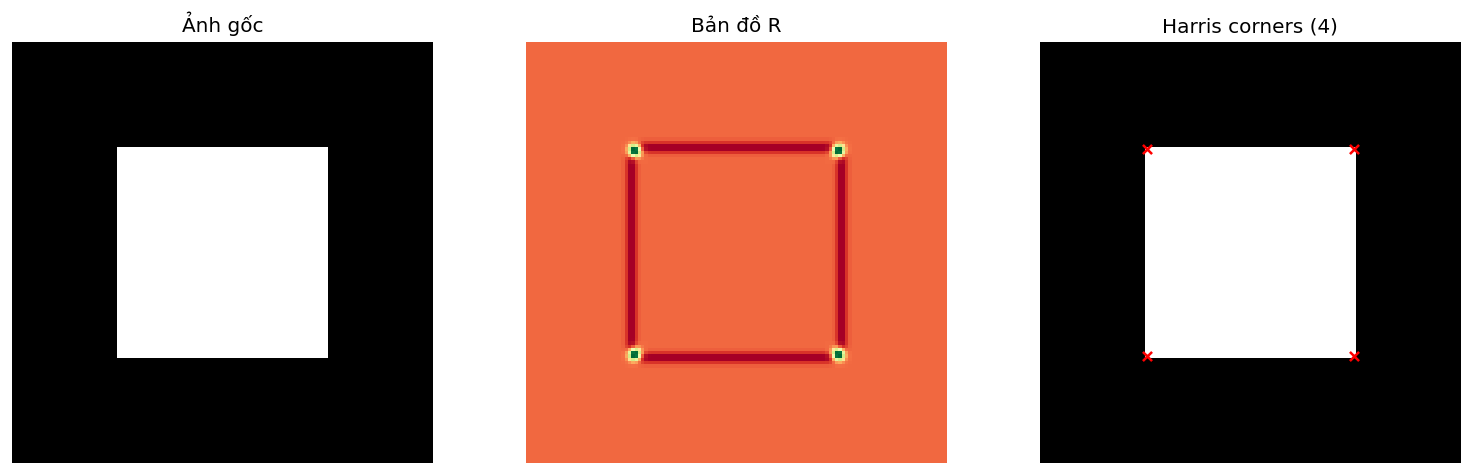

In [ ]:
# Ảnh thử nghiệm cho Harris
img_harris_test = make_test_image('rect', N=128)

R, corners = harris_detector(img_harris_test, sigma=1.5, k=0.05,
                              threshold_ratio=0.01, nms_window=9)

ys, xs = np.where(corners)
print(f'Số góc phát hiện: {len(xs)}')

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(img_harris_test, cmap='gray'); axes[0].set_title('Ảnh gốc')
axes[1].imshow(R, cmap='RdYlGn'); axes[1].set_title('Bản đồ R')
axes[2].imshow(img_harris_test, cmap='gray')
axes[2].scatter(xs, ys, s=30, c='red', marker='x', linewidths=1.5)
axes[2].set_title(f'Harris corners ({len(xs)})')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()


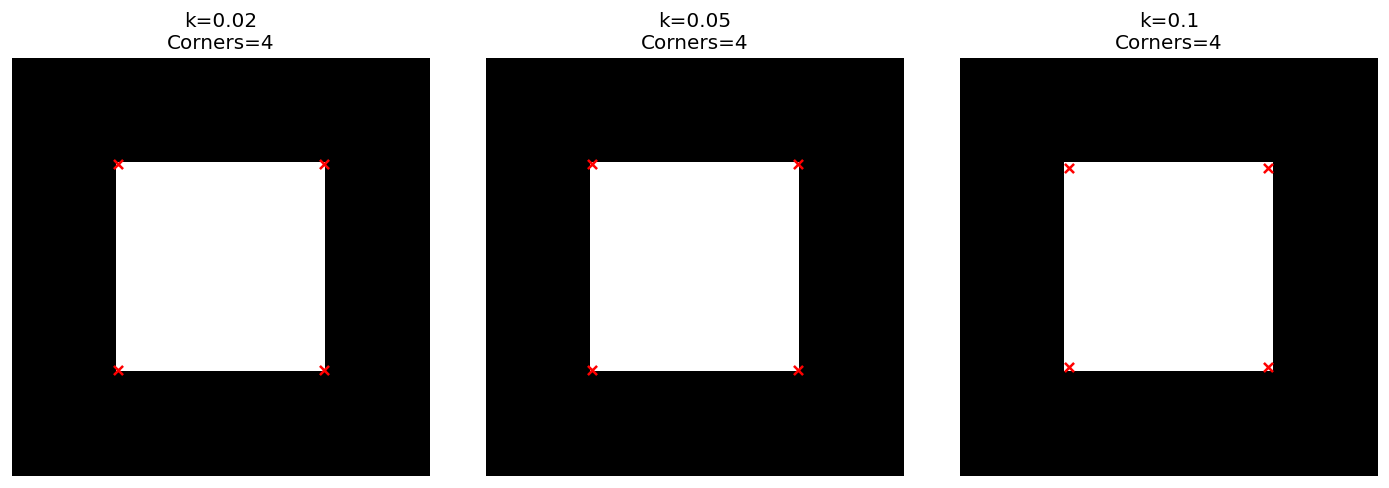

In [ ]:
# Thử nghiệm ảnh hưởng của tham số k và sigma
# TODO: chạy harris_detector với k = 0.02, 0.05, 0.10 và so sánh số góc
for k_val in [0.02, 0.05, 0.10]:
    pass  # TODO
fig, axes = plt.subplots(1, 3, figsize=(12,4))

for ax, k_val in zip(
        axes,
        [0.02, 0.05, 0.10]
    ):

    R, corners = harris_detector(
        img_harris_test,
        sigma=1.5,
        k=k_val,
        threshold_ratio=0.01,
        nms_window=9
    )

    ys, xs = np.where(corners)

    ax.imshow(img_harris_test, cmap='gray')
    ax.scatter(xs, ys,
               c='red',
               marker='x',
               s=30)

    ax.set_title(
        f'k={k_val}\nCorners={len(xs)}'
    )

    ax.axis('off')

plt.tight_layout()
plt.show()

## 2.2 Harris-Laplace

Kết hợp Harris (phát hiện góc) với phân tích thang đo qua LoG chuẩn hoá:
$$\sigma^* = \arg\max_\sigma |\sigma^2 \nabla^2 L(\mathbf{x},\sigma)|$$

Xấp xỉ LoG bằng DoG: $\sigma^2 \nabla^2 L \approx \frac{1}{k-1}[L(k\sigma) - L(\sigma)]$


In [ ]:
def harris_laplace(img, sigmas=None, k=0.05, threshold_ratio=0.01):
    """Harris-Laplace: phát hiện góc bất biến thang đo"""
    if sigmas is None:
        sigmas = [1.0, 1.6, 2.5, 4.0, 6.4]
    
    num_scales = len(sigmas)
    H, W = img.shape

    L = []
    for s in sigmas:
        L.append(gaussian_blur(img, sigma=s))

    corner_masks = []
    for i, s in enumerate(sigmas):
        _, corners = harris_detector(L[i], sigma=s, k=k, threshold_ratio=threshold_ratio)
        corner_masks.append(corners)

    LoG_norm = []
    for i in range(num_scales - 1):
        k_ratio = sigmas[i+1] / sigmas[i]
        dog = (L[i+1] - L[i]) / (k_ratio - 1.0)
        LoG_norm.append(dog)
 
    LoG_norm_3d = np.abs(np.stack(LoG_norm, axis=0))
    keypoints = []

    for i in range(1, len(LoG_norm) - 1):

        rows, cols = np.where(corner_masks[i])
        
        for r, c in zip(rows, cols):
            val_curr = LoG_norm_3d[i, r, c]
            val_prev = LoG_norm_3d[i-1, r, c] # Tầng dưới
            val_next = LoG_norm_3d[i+1, r, c] # Tầng trên

            if val_curr > val_prev and val_curr > val_next:
                sigma_star = sigmas[i]
                keypoints.append((r, c, sigma_star))
                
    return keypoints

In [ ]:
# Thử nghiệm Harris-Laplace
img_hl = make_test_image('circles', N=128)

kps = harris_laplace(img_hl, sigmas=[1.0, 1.6, 2.5, 4.0, 6.4])
print(f'Số keypoints Harris-Laplace: {len(kps)}')

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img_hl, cmap='gray')
for (r, c, s) in kps:
    circle = plt.Circle((c, r), radius=3*s, fill=False, color='lime', linewidth=1.5)
    ax.add_patch(circle)
    ax.plot(c, r, 'r.', markersize=4)
ax.set_title(f'Harris-Laplace ({len(kps)} keypoints)\nVòng tròn tỉ lệ σ*')
ax.axis('off'); plt.tight_layout(); plt.show()


In [ ]:
# So sánh Harris chuẩn vs Harris-Laplace khi ảnh bị thu nhỏ
from scipy.ndimage import zoom as sp_zoom

img_full = make_test_image('circles', N=128)
img_half = np.clip(sp_zoom(img_full, 0.5), 0, 1)

# TODO: chạy Harris và Harris-Laplace trên cả hai ảnh
# So sánh: Harris-Laplace có phát hiện được cùng keypoints không?


## 2.3 FAST — Features from Accelerated Segment Test

Pixel $p$ là góc nếu tồn tại cung $n=12$ pixel liên tiếp trên vòng tròn Bresenham bán kính 3,
tất cả đều sáng hơn $I_p + t$ hoặc tối hơn $I_p - t$.

**Kiểm tra nhanh:** Chỉ kiểm tra pixel 1, 5, 9, 13 trước — nếu $<3$ pixel thoả thì bỏ ngay.


In [ ]:
# 16 pixel trên vòng tròn Bresenham bán kính 3 (theo thứ tự)
CIRCLE_16 = np.array([
    ( 0, 3),( 1, 3),( 2, 2),( 3, 1),
    ( 3, 0),( 3,-1),( 2,-2),( 1,-3),
    ( 0,-3),(-1,-3),(-2,-2),(-3,-1),
    (-3, 0),(-3, 1),(-2, 2),(-1, 3)
])  # offset (dy, dx)

# Bốn pixel kiểm tra nhanh (vị trí 0, 4, 8, 12 trong CIRCLE_16)
FAST4 = [0, 4, 8, 12]

def fast_is_corner(img, r, c, t, n=12):
    """Kiểm tra pixel (r,c) có phải góc FAST không.
    
    Args:
        img: ảnh grayscale float64 hoặc uint8
        r, c: toạ độ pixel
        t:    ngưỡng
        n:    độ dài cung tối thiểu (mặc định 12)
    
    Returns:
        is_corner: bool
        score:     độ dài cung lớn nhất (dùng cho NMS)
    """
    Ip = img[r, c]
    
    
    raise NotImplementedError

def fast_detector(img, t=20, n=12, nms=True, nms_window=7):
    """FAST corner detector từ đầu.
    
    Args:
        img:        ảnh grayscale, float64 trong [0,1] hoặc uint8 [0,255]
        t:          ngưỡng (nếu img float: t nên trong [0,1])
        n:          độ dài cung tối thiểu
        nms:        có áp NMS không
        nms_window: kích thước cửa sổ NMS
    
    Returns:
        keypoints: list of (row, col)
        score_map: bản đồ điểm số (0 nếu không phải góc)
    """
    H, W = img.shape
    score_map = np.zeros((H, W), dtype=np.float64)
    
    # Duyệt qua tất cả pixel, bỏ qua biên (bán kính 3)
    for r in range(3, H-3):
        for c in range(3, W-3):
            is_c, score = fast_is_corner(img, r, c, t, n)
            if is_c:
                score_map[r, c] = score
    
    if nms:
        keep = nms_2d(score_map, nms_window, threshold=0.5)
        keypoints = list(zip(*np.where(keep)))
    else:
        keypoints = list(zip(*np.where(score_map > 0)))
    
    return keypoints, score_map


NameError: name 'np' is not defined

In [ ]:
# Ảnh thử nghiệm FAST
img_fast_test = make_test_image('rect', N=128)

kps_fast, smap = fast_detector(img_fast_test, t=0.1, n=12, nms=True)
print(f'Số keypoints FAST: {len(kps_fast)}')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(smap, cmap='hot'); axes[0].set_title('Score map FAST')
axes[1].imshow(img_fast_test, cmap='gray')
if kps_fast:
    ys, xs = zip(*kps_fast)
    axes[1].scatter(xs, ys, s=20, c='red', marker='x')
axes[1].set_title(f'FAST keypoints ({len(kps_fast)})')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()


In [ ]:
# Thử nghiệm: thay đổi ngưỡng t
for t_val in [0.05, 0.10, 0.20, 0.35]:
    kps, _ = fast_detector(img_fast_test, t=t_val, n=12)
    print(f't={t_val:.2f}: {len(kps)} keypoints')


## 2.4 So sánh ba phương pháp (Được phép dùng AI để hỗ trợ, nhưng phải nêu được ý tưởng chính)

Chạy Harris, Harris-Laplace, và FAST trên cùng ảnh. So sánh:
1. Số keypoints phát hiện
2. Phân bố không gian
3. Độ ổn định khi xoay ảnh


---
# Bài 3 — Simplified SIFT

**Pipeline:**
1. Xây dựng DoG pyramid (scale space + DoG)
2. Tìm cực trị 26 lân cận → keypoint ứng viên
3. Lọc tương phản thấp
4. Gán hướng chủ đạo $\theta^*$ (histogram 36 bin)
5. Xây dựng descriptor 32D ($2\times2\times8$, nearest-neighbor)
6. Kiểm chứng bất biến góc quay và thang đo

> **Lưu ý:** Bỏ qua tinh chỉnh Taylor (Bước 2a), lọc cạnh Hessian (Bước 2c),
> bilinear interpolation (dùng nearest-neighbor), keypoint phụ (Bước 3b).


## 3.0 Ảnh thử nghiệm cho SIFT


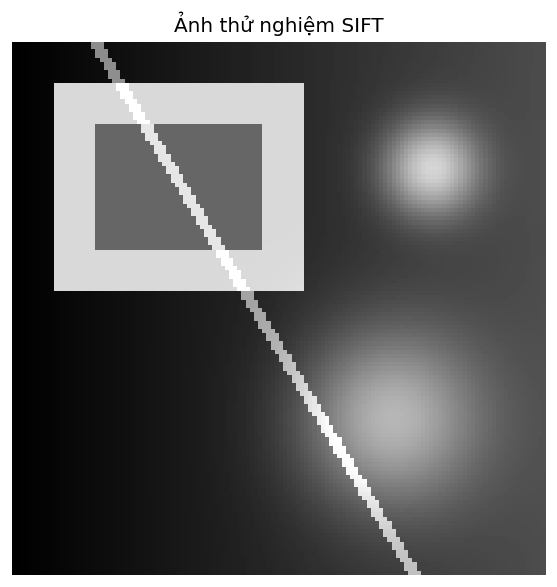

In [13]:
def make_sift_test_image(N=128):
    """Ảnh tổng hợp có nhiều cấu trúc ở nhiều kích thước khác nhau."""
    img = np.zeros((N, N), dtype=np.float64)
    # Gradient nền nhẹ
    img += np.linspace(0, 0.3, N)[np.newaxis, :]
    # Hình chữ nhật lớn
    img[10:60, 10:70] = 0.85
    img[20:50, 20:60] = 0.40
    # Đường chéo
    for i in range(N):
        j = int(i * 0.6 + 20)
        if 0 <= j < N:
            img[i, max(0,j-1):min(N,j+2)] = min(1.0, img[i,j] + 0.5)
    # Blob nhỏ
    yy, xx = np.ogrid[:N, :N]
    img += 0.6 * np.exp(-((xx-100)**2 + (yy-30)**2) / (2*8**2))
    img += 0.5 * np.exp(-((xx-90)**2 + (yy-90)**2) / (2*15**2))
    return np.clip(img, 0, 1)

img_sift = make_sift_test_image(128)
plt.figure(figsize=(5,5))
plt.imshow(img_sift, cmap='gray'); plt.title('Ảnh thử nghiệm SIFT'); plt.axis('off')
plt.tight_layout(); plt.show()


## 3.1 Scale Space và DoG Pyramid

**Scale space:** $L(x,y,\sigma) = G_\sigma * f$

**Tính chất nửa nhóm:** $G_{\sigma_1} * G_{\sigma_2} = G_{\sqrt{\sigma_1^2+\sigma_2^2}}$

Thay vì blur từ ảnh gốc tại mỗi $\sigma$, blur từ tầng trước với $\sigma_\Delta = \sqrt{\sigma_{i+1}^2 - \sigma_i^2}$.

**DoG:** $D(x,y,\sigma_i) = L(x,y,k\sigma_i) - L(x,y,\sigma_i)$

DoG xấp xỉ LoG chuẩn hoá thang đo và rẻ vì kim tự tháp Gaussian đã phải tính.


In [14]:
def build_dog_pyramid(img, n_octaves=3, n_scales=3, sigma0=1.6):
    """Xây dựng kim tự tháp Gaussian và DoG.
    
    Args:
        img:       ảnh float64 [0,1], kích thước H×W
        n_octaves: số octave
        n_scales:  số tầng hữu dụng mỗi octave (s=3 theo Lowe)
        sigma0:    sigma gốc (1.6 theo Lowe)
    
    Returns:
        gaussians: list[n_octaves][n_scales+3] — ảnh Gaussian
        dogs:      list[n_octaves][n_scales+2] — ảnh DoG
        sigmas:    list[n_octaves][n_scales+3] — sigma tương ứng
    """
    k = 2 ** (1.0 / n_scales)  # tỉ lệ sigma giữa hai tầng liên tiếp
    n_layers = n_scales + 3    # số ảnh Gaussian mỗi octave
    
    # Tạo danh sách lưu kết quả
    gaussians = []
    dogs      = []
    sigmas_all = []

    # Octave đầu tiên dùng ảnh gốc
    # Dùng copy để tách riêng dữ liệu
    current = img.copy() 

    # Vòng lặp octave
    for octave in range(n_octaves):

        # Khởi tạo octave hiện tại 
        octave_gaussians = []
        octave_sigmas = []

        # Tầng đầu tiên
        octave_gaussians.append( current.copy())
        octave_sigmas.append(sigma0)

        # Tạo từng tầng Gaussian còn lại
        for i in range(1, n_layers):
    
            # Tính sigma
            sigma_prev = sigma0 * (k ** (i - 1)) # sigma tầng trước
            sigma_curr = sigma0 * (k ** i) # sigma tầng hiện tại
            sigma_delta = np.sqrt(sigma_curr**2 -sigma_prev**2) # sigma cần blur thêm

            # Blur từ Gausian trước
            blurred = gaussian_filter(
                octave_gaussians[-1],
                sigma=sigma_delta
            )

            # Lưu Gaussian & sigma mới
            octave_gaussians.append(blurred)
            octave_sigmas.append(sigma_curr)
    
        # Tạo danh sách DoG: DoG được lưu riêng
        octave_dogs = []

        # Hiệu hai Gaussian liên tiếp
        for i in range(len(octave_gaussians)-1):
            dog = (octave_gaussians[i+1] - octave_gaussians[i])

            # Lưu DoG
            octave_dogs.append(dog)

        # Lưu toàn bộ octave
        gaussians.append(octave_gaussians)
        dogs.append(octave_dogs)
        sigmas_all.append(octave_sigmas)
        
        # Chọn ảnh gốc cho octave tiếp theo
        base = octave_gaussians[n_scales]

        # Giảm kích thước ảnh 1/2
        current = base[::2, ::2].copy()

    return gaussians, dogs, sigmas_all


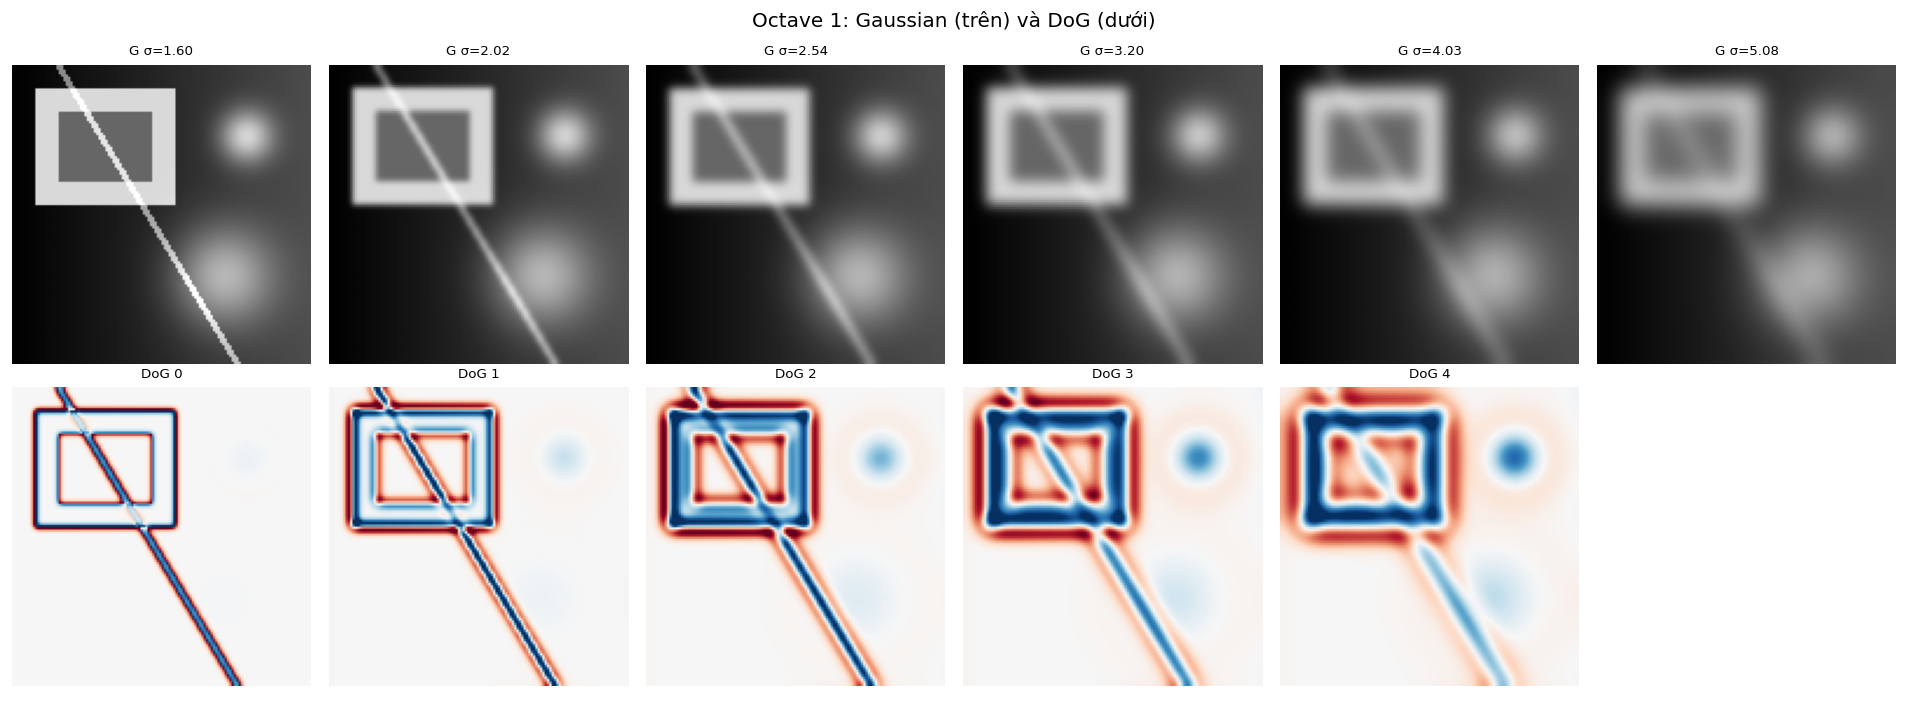

Octave 1: 128×128 pixel, 6 Gaussian, 5 DoG
Octave 2: 64×64 pixel, 6 Gaussian, 5 DoG
Octave 3: 32×32 pixel, 6 Gaussian, 5 DoG


In [15]:
# Kiểm tra và visualise pyramid
gaussians, dogs, sigmas = build_dog_pyramid(img_sift, n_octaves=3, n_scales=3, sigma0=1.6)

# Hiển thị octave đầu: Gaussian + DoG
if gaussians[0] and dogs[0]:
    n_g = len(gaussians[0])
    n_d = len(dogs[0])
    fig, axes = plt.subplots(2, max(n_g, n_d), figsize=(16, 6))
    for i, (g, s) in enumerate(zip(gaussians[0], sigmas[0])):
        axes[0, i].imshow(g, cmap='gray', vmin=0, vmax=1)
        axes[0, i].set_title(f'G σ={s:.2f}', fontsize=8); axes[0, i].axis('off')
    for i, d in enumerate(dogs[0]):
        vm = np.percentile(np.abs(d), 98) + 1e-8
        axes[1, i].imshow(d, cmap='RdBu_r', vmin=-vm, vmax=vm)
        axes[1, i].set_title(f'DoG {i}', fontsize=8); axes[1, i].axis('off')
    # Tắt axes thừa
    for j in range(n_d, max(n_g, n_d)):
        axes[1, j].axis('off')
    plt.suptitle('Octave 1: Gaussian (trên) và DoG (dưới)')
    plt.tight_layout(); plt.show()

    # Kiểm tra kích thước qua các octave
    for oct_idx in range(len(gaussians)):
        if gaussians[oct_idx]:
            h, w = gaussians[oct_idx][0].shape
            print(f'Octave {oct_idx+1}: {h}×{w} pixel, '
                  f'{len(gaussians[oct_idx])} Gaussian, {len(dogs[oct_idx])} DoG')


## 3.2 Phát hiện cực trị 26 lân cận

Một pixel $(x_0, y_0)$ trong tầng DoG giữa là ứng viên keypoint nếu $D(x_0,y_0,\sigma_0)$
lớn hơn (hoặc nhỏ hơn) tất cả 26 lân cận: 8 cùng tầng + 9 tầng trên + 9 tầng dưới.

Sau đó lọc: chỉ giữ nếu $|D(x_0,y_0,\sigma_0)| \ge \tau_c = 0.03$.


In [ ]:
def find_dog_extrema(dogs, sigmas, tau_c=0.03, border=5):
    """Tìm cực trị cục bộ trong 26 lân cận của DoG pyramid.
    
    Args:
        dogs:   list[n_octaves][n_layers] — ảnh DoG
        sigmas: list[n_octaves][n_layers] — sigma tương ứng Gaussian
        tau_c:  ngưỡng tương phản tối thiểu
        border: số pixel bỏ qua ở biên
    
    Returns:
        keypoints: list of dict với keys:
                   'oct'   — chỉ số octave
                   'layer' — chỉ số tầng DoG (tầng giữa)
                   'r', 'c' — toạ độ trong octave đó
                   'sigma' — sigma* của keypoint
                   'dog_val' — giá trị DoG tại keypoint
    """
    keypoints = []
    
    for oct_idx, oct_dogs in enumerate(dogs):
        # Duyệt qua các tầng giữa (không phải tầng đầu và cuối)
        for layer in range(1, len(oct_dogs) - 1):
            D_prev = oct_dogs[layer - 1]  # tầng dưới
            D_curr = oct_dogs[layer]       # tầng hiện tại
            D_next = oct_dogs[layer + 1]   # tầng trên
            H, W   = D_curr.shape

    
    return keypoints


In [ ]:
keypoints = find_dog_extrema(dogs, sigmas, tau_c=0.03)
print(f'Số keypoints sau lọc tương phản: {len(keypoints)}')

# Visualise keypoints với vòng tròn tỉ lệ sigma*
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for oct_idx in range(min(3, len(gaussians))):
    if not gaussians[oct_idx]: continue
    ax = axes[oct_idx]
    ax.imshow(gaussians[oct_idx][0], cmap='gray', vmin=0, vmax=1)
    kps_oct = [kp for kp in keypoints if kp['oct'] == oct_idx]
    for kp in kps_oct:
        c = plt.Circle((kp['c'], kp['r']),
                        radius=3*kp['sigma'], fill=False,
                        color='lime' if kp['dog_val']>0 else 'red',
                        linewidth=1.0)
        ax.add_patch(c)
        ax.plot(kp['c'], kp['r'], '.', color='lime' if kp['dog_val']>0 else 'red', ms=2)
    ax.set_title(f'Octave {oct_idx+1}: {len(kps_oct)} keypoints')
    ax.axis('off')
plt.suptitle('Keypoints DoG (xanh=cực đại, đỏ=cực tiểu, vòng tròn ∝ σ*)')
plt.tight_layout(); plt.show()


## 3.3 Gán hướng chủ đạo $\theta^*$

Tại thang $\sigma^*$, tính gradient trong vùng bán kính $r = 4.5\sigma^*$ quanh keypoint.
Xây dựng histogram 36 bin với trọng số = biên độ gradient $\times$ Gaussian $\sigma_w = 1.5\sigma^*$.
$\theta^*$ = bin cao nhất.

**Quan trọng:** gradient phải tính từ $L(\cdot, \sigma^*)$, không phải ảnh gốc.


In [ ]:
def assign_orientations(keypoints, gaussians, sigmas, n_bins=36):
    """Gán hướng chủ đạo cho mỗi keypoint.
    
    Args:
        keypoints: list of dicts từ find_dog_extrema
        gaussians: kim tự tháp Gaussian
        sigmas:    sigma tương ứng
        n_bins:    số bin histogram (36 theo Lowe)
    
    Returns:
        keypoints_with_orient: list of dicts, thêm key 'theta' (degrees)
    """
    bin_width = 360.0 / n_bins  # 10 degrees per bin
    result = []
    
    for kp in keypoints:
        oct_idx = kp['oct']
        layer   = kp['layer']
        r0, c0  = kp['r'], kp['c']
        sigma_s = kp['sigma']  #

        #TO DO

        theta_star = 0.0               #lấy từ histogram
        
        result.append({**kp, 'theta': theta_star, 'histogram': histogram})
    
    return result


In [ ]:
keypoints_oriented = assign_orientations(keypoints, gaussians, sigmas)
print(f'Keypoints với hướng: {len(keypoints_oriented)}')

# Visualise vài keypoint với hướng
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
ax = axes[0]
ax.imshow(img_sift, cmap='gray', vmin=0, vmax=1)

# Chỉ vẽ keypoints octave 0 để dễ nhìn
kps_oct0 = [kp for kp in keypoints_oriented if kp['oct'] == 0]
for kp in kps_oct0[:30]:  # top 30
    r, c, s, th = kp['r'], kp['c'], kp['sigma'], kp['theta']
    circle = plt.Circle((c, r), 3*s, fill=False, color='lime', lw=1)
    ax.add_patch(circle)
    # Vẽ mũi tên hướng
    dx = 3*s * np.cos(np.radians(th))
    dy = 3*s * np.sin(np.radians(th))
    ax.annotate('', xy=(c+dx, r+dy), xytext=(c, r),
                arrowprops=dict(arrowstyle='->', color='yellow', lw=1.2))
ax.set_title(f'Keypoints + hướng θ* (octave 1, top 30)')
ax.axis('off')

# Histogram hướng của một keypoint
if kps_oct0:
    kp = kps_oct0[0]
    hist = kp['histogram']
    bins_deg = np.arange(36) * 10 + 5
    axes[1].bar(bins_deg, hist, width=9, color='steelblue', edgecolor='navy', alpha=0.85)
    axes[1].axvline(kp['theta'], color='red', lw=2, label=f"θ*={kp['theta']:.1f}°")
    axes[1].set_xlabel('Hướng (°)'); axes[1].set_ylabel('Trọng số tích lũy')
    axes[1].set_title(f"Histogram 36 bin của keypoint 0 (σ*={kp['sigma']:.2f})")
    axes[1].legend(); axes[1].set_xlim(0, 360); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## 3.4 Xây dựng Descriptor 32D

Descriptor mô tả vùng $8\times8$ pixel trong **hệ toạ độ cục bộ** xoay theo $\theta^*$, chuẩn hoá theo $\sigma^*$.

**Hệ toạ độ cục bộ:** pixel tại lưới $(i,j)$ tương ứng toạ độ ảnh:
$$\begin{bmatrix}x\\y\end{bmatrix} = \begin{bmatrix}x_0\\y_0\end{bmatrix} + \sigma^* R_{\theta^*} \begin{bmatrix}i\\j\end{bmatrix}$$

Dùng **nearest-neighbor**: làm tròn $(x,y)$ về pixel gần nhất.

Chia $8\times8$ thành lưới $2\times2$ ô ($4\times4$ pixel mỗi ô) → 4 histogram 8 bin → vector 32D → chuẩn hoá L2.


In [ ]:
def compute_descriptors(keypoints_oriented, gaussians, sigmas,
                         grid_size=2, patch_per_cell=4, n_bins=8):
    """Xây dựng descriptor 32D cho mỗi keypoint.
    
    Args:
        keypoints_oriented: list of dicts với 'theta', 'sigma', 'r', 'c', 'oct', 'layer'
        gaussians:          kim tự tháp Gaussian
        sigmas:             sigma tương ứng
        grid_size:          số ô mỗi chiều (2 → lưới 2×2)
        patch_per_cell:     số pixel cục bộ mỗi ô mỗi chiều (4)
        n_bins:             số bin histogram hướng (8 → 45°/bin)
    
    Returns:
        descriptors: np.ndarray shape (K, grid_size^2 * n_bins)
                     = (K, 32) với grid_size=2, n_bins=8
    """
    half = grid_size * patch_per_cell // 2  # = 4: vùng [-4,3] cục bộ
    bin_width = 360.0 / n_bins              # = 45 degrees
    desc_dim  = grid_size * grid_size * n_bins  # = 32
    
    descriptors = []
    
    for kp in keypoints_oriented:
        oct_idx = kp['oct']
        layer   = kp['layer']
        r0, c0  = kp['r'], kp['c']
        sigma_s = kp['sigma']
        theta   = kp['theta']  # degrees
        
        # Ảnh Gaussian tại thang sigma*
        L = gaussians[oct_idx][min(layer + 1, len(gaussians[oct_idx]) - 1)]
        H, W = L.shape
        
        cos_t = np.cos(np.radians(theta))
        sin_t = np.sin(np.radians(theta))
        
        # Khởi tạo lưới histogram: shape (grid_size, grid_size, n_bins)
        grid_hist = np.zeros((grid_size, grid_size, n_bins))

        for i in range(-half, half):
            for j in range(-half, half):
                c_rot = int(round(c0 + i * cos_t - j * sin_t))
                r_rot = int(round(r0 + i * sin_t + j * cos_t))

                if r_rot < 1 or r_rot >= H - 1 or c_rot < 1 or c_rot >= W - 1:
                    continue

                dr = L[r_rot + 1, c_rot] - L[r_rot - 1, c_rot]
                dc = L[r_rot, c_rot + 1] - L[r_rot, c_rot - 1]
                
                magnitude = np.sqrt(dr**2 + dc**2)

                orientation = np.degrees(np.arctan2(dr, dc)) % 360.0

                rel_orientation = (orientation - theta) % 360.0
                bin_idx = int(rel_orientation // bin_width) % n_bins
                
                cell_r = (i + half) // patch_per_cell
                cell_c = (j + half) // patch_per_cell
                
                if 0 <= cell_r < grid_size and 0 <= cell_c < grid_size:
                    grid_hist[cell_r, cell_c, bin_idx] += magnitude
                    
        desc = grid_hist.flatten()

        norm = np.linalg.norm(desc)
        if norm > 1e-6:
            desc = desc / norm
        else:
            desc = np.zeros(desc_dim)

        descriptors.append(desc)
    
    return np.array(descriptors) if descriptors else np.zeros((0, desc_dim))


In [ ]:
descriptors = compute_descriptors(keypoints_oriented, gaussians, sigmas)
print(f'Descriptor matrix shape: {descriptors.shape}')
print(f'Norm của descriptor đầu tiên: {np.linalg.norm(descriptors[0]):.4f} (phải ≈ 1.0)')

# Visualise descriptor
if len(descriptors) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    
    # Heatmap ma trận descriptor
    n_show = min(20, len(descriptors))
    im = axes[0].imshow(descriptors[:n_show], cmap='viridis', aspect='auto')
    axes[0].set_title(f'{n_show} descriptors × 32D'); axes[0].set_xlabel('Chiều')
    plt.colorbar(im, ax=axes[0], fraction=0.03)
    
    # Bar chart descriptor đầu tiên
    axes[1].bar(range(32), descriptors[0], color='steelblue', width=0.9)
    for b in range(1, 4):  # ranh giới 4 ô
        axes[1].axvline(b*8 - 0.5, color='red', lw=1.5, ls='--', alpha=0.7)
    axes[1].set_title('Descriptor kp[0] — 4 ô × 8 bin')
    axes[1].set_xlabel('Chiều (0–31)'); axes[1].grid(True, alpha=0.3)
    axes[1].set_xticks([3.5, 11.5, 19.5, 27.5])
    axes[1].set_xticklabels(['Ô(0,0)', 'Ô(0,1)', 'Ô(1,0)', 'Ô(1,1)'])
    
    # Phân phối norm
    norms = np.linalg.norm(descriptors, axis=1)
    axes[2].hist(norms, bins=20, color='tomato', edgecolor='darkred', alpha=0.85)
    axes[2].set_title('Phân phối norm descriptor'); axes[2].set_xlabel('Norm')
    axes[2].axvline(1.0, color='blue', lw=2, ls='--', label='Norm = 1')
    axes[2].legend(); axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout(); plt.show()


## 3.5 Kiểm chứng tính bất biến (cho phép dùng AI để hỗ trợ lập trình phần này, nhưng phải nêu được ý tưởng)

### 3.5a Bất biến góc quay
Tính descriptor của cùng cấu trúc trong ảnh gốc và ảnh xoay. Khoảng cách Euclid giữa hai descriptor phải nhỏ hơn đáng kể so với khoảng cách giữa hai keypoints ngẫu nhiên.


### 3.5b Bất biến thang đo
Tính descriptor trên ảnh phóng to $1.5\times$. Descriptor của cùng cấu trúc vật lý phải tương tự nhau.


In [ ]:
from scipy.ndimage import rotate, zoom

def rotate_image(img, angle):
    return rotate(img, angle, reshape=False, order=1, mode='reflect')

def scale_image(img, factor):
    return zoom(img, factor, order=1)

def find_nearest_keypoint(keypoints, target_r, target_c, oct_idx=None):
    candidates = [kp for kp in keypoints if oct_idx is None or kp['oct'] == oct_idx]
    if not candidates:
        return None
    distances = [np.hypot(kp['r'] - target_r, kp['c'] - target_c) for kp in candidates]
    return candidates[int(np.argmin(distances))]

# 3.5a: Bất biến góc quay
angle = 30.0
img_rot = rotate_image(img_sift, angle)
gauss_rot, dogs_rot, sigmas_rot = build_dog_pyramid(img_rot, n_octaves=3, n_scales=3, sigma0=1.6)
kps_rot = find_dog_extrema(dogs_rot, sigmas_rot, tau_c=0.03)
kps_rot_oriented = assign_orientations(kps_rot, gauss_rot, sigmas_rot)

kps_orig_oct0 = [kp for kp in keypoints if kp['oct'] == 0]
if len(kps_orig_oct0) == 0:
    raise ValueError("Không tìm thấy keypoint octave 0 trên ảnh gốc.")
kp_orig = kps_orig_oct0[0]

h, w = img_sift.shape
cx, cy = (w - 1) / 2.0, (h - 1) / 2.0
rad = np.radians(angle)
cos_a, sin_a = np.cos(rad), np.sin(rad)
c_rot = (kp_orig['c'] - cx) * cos_a - (kp_orig['r'] - cy) * sin_a + cx
r_rot = (kp_orig['c'] - cx) * sin_a + (kp_orig['r'] - cy) * cos_a + cy
kp_rot = find_nearest_keypoint(kps_rot_oriented, r_rot, c_rot)
if kp_rot is None:
    raise ValueError("Không tìm thấy keypoint tương ứng trên ảnh xoay.")

desc_orig = compute_descriptors([kp_orig], gaussians, sigmas)[0]
desc_rot = compute_descriptors([kp_rot], gauss_rot, sigmas_rot)[0]
rot_dist = np.linalg.norm(desc_orig - desc_rot)
random_indices = np.random.default_rng(123).choice(len(kps_rot_oriented), size=min(20, len(kps_rot_oriented)), replace=False)
random_dists = []
for idx in random_indices:
    kp_test = kps_rot_oriented[idx]
    if kp_test is kp_rot:
        continue
    d = np.linalg.norm(desc_orig - compute_descriptors([kp_test], gauss_rot, sigmas_rot)[0])
    random_dists.append(d)

print("### 3.5a: Bất biến góc quay")
print(f"Keypoint gốc (oct=0): r={kp_orig['r']}, c={kp_orig['c']}, sigma={kp_orig['sigma']:.2f}")
print(f"Keypoint xoay gần nhất: r={kp_rot['r']:.1f}, c={kp_rot['c']:.1f}, sigma={kp_rot['sigma']:.2f}, theta={kp_rot['theta']:.1f}")
print(f"Khoảng cách Euclid descriptor tương ứng: {rot_dist:.4f}")
if random_dists:
    print(f"Median khoảng cách descriptor ngẫu nhiên: {np.median(random_dists):.4f}")
    print(f"Min khoảng cách descriptor ngẫu nhiên: {np.min(random_dists):.4f}")

# 3.5b: Bất biến thang đo
scale_factor = 1.5
img_scale = scale_image(img_sift, scale_factor)
gauss_scale, dogs_scale, sigmas_scale = build_dog_pyramid(img_scale, n_octaves=3, n_scales=3, sigma0=1.6)
kps_scale = find_dog_extrema(dogs_scale, sigmas_scale, tau_c=0.03)
kps_scale_oriented = assign_orientations(kps_scale, gauss_scale, sigmas_scale)
c_scaled = kp_orig['c'] * scale_factor
r_scaled = kp_orig['r'] * scale_factor
kp_scaled = find_nearest_keypoint(kps_scale_oriented, r_scaled, c_scaled)
if kp_scaled is None:
    raise ValueError("Không tìm thấy keypoint tương ứng trên ảnh phóng to.")
desc_scale = compute_descriptors([kp_scaled], gauss_scale, sigmas_scale)[0]
scale_dist = np.linalg.norm(desc_orig - desc_scale)
random_indices = np.random.default_rng(456).choice(len(kps_scale_oriented), size=min(20, len(kps_scale_oriented)), replace=False)
random_dists_scale = []
for idx in random_indices:
    kp_test = kps_scale_oriented[idx]
    if kp_test is kp_scaled:
        continue
    d = np.linalg.norm(desc_orig - compute_descriptors([kp_test], gauss_scale, sigmas_scale)[0])
    random_dists_scale.append(d)

print("### 3.5b: Bất biến thang đo")
print(f"Keypoint phóng to gần nhất: r={kp_scaled['r']:.1f}, c={kp_scaled['c']:.1f}, sigma={kp_scaled['sigma']:.2f}, theta={kp_scaled['theta']:.1f}")
print(f"Khoảng cách Euclid descriptor tương ứng: {scale_dist:.4f}")
if random_dists_scale:
    print(f"Median khoảng cách descriptor ngẫu nhiên: {np.median(random_dists_scale):.4f}")
    print(f"Min khoảng cách descriptor ngẫu nhiên: {np.min(random_dists_scale):.4f}")
